# 1) Newton's Law of Cooling

At the scene of a crime a person was found dead. Can you determine the time of death? The temperature of the body was measured to be 32.0+/-0.2 degC at 5:00 pm and at 28.5+/-0.3 degC on hour later at 6:00 pm. The room temeprature was 22.0+/-1.0 degC. Estimate the time of death with the uncertainty.


In [ ]:
import sys
sys.path.append("../src")

from augment import Sampler
from augment.format import format_summary
from augment.plot import plot_posterior

import numpy as np
from astropy import units as u
from scipy.integrate import solve_ivp

sampler = Sampler(n_samples=30000, seed=42)

sampler.add("T1", 32.0 * u.deg_C, upper_error=0.2 * u.deg_C, lower_error=0.2 * u.deg_C, dist="normal")
sampler.add("T2", 28.5 * u.deg_C, upper_error=0.3 * u.deg_C, lower_error=0.3 * u.deg_C, dist="normal")
sampler.add("Te", 22.0 * u.deg_C, upper_error=1.0 * u.deg_C, lower_error=1.0 * u.deg_C, dist="normal")
sampler.add("T0", 37.0 * u.deg_C, upper_error=0.5 * u.deg_C, lower_error=0.5 * u.deg_C, dist="normal")

def t_death(T1, T2, Te, T0, dt=1.0 * u.hour, tmax=24.0 * u.hour):
    T1K = T1.to_value(u.K, equivalencies=u.temperature())
    T2K = T2.to_value(u.K, equivalencies=u.temperature())
    TeK = Te.to_value(u.K, equivalencies=u.temperature())
    T0K = T0.to_value(u.K, equivalencies=u.temperature())

    out = np.full(T1K.shape, np.nan, dtype=float)
    dt_hr = dt.to_value(u.hour)
    tmax_hr = tmax.to_value(u.hour)

    for i in range(T1K.size):
        t1 = T1K[i]
        t2 = T2K[i]
        te = TeK[i]
        t0 = T0K[i]

        if not np.all(np.isfinite([t1, t2, te, t0])):
            continue
        if (t1 <= te) or (t2 <= te) or (t1 <= t2) or (t0 <= te):
            continue
        ratio = (t1 - te) / (t2 - te)
        if ratio <= 0:
            continue
        k = np.log(ratio) / dt_hr
        if k <= 0:
            continue

        def dTdt(t, y):
            return -k * (y - te)

        def hit_T0(t, y):
            return y - t0
        hit_T0.terminal = True
        hit_T0.direction = 0

        sol = solve_ivp(dTdt, (0.0, -tmax_hr), [t1], events=hit_T0, max_step=0.05)
        if sol.t_events[0].size > 0:
            out[i] = -sol.t_events[0][0]

    return out * u.hour

out = sampler.run(t_death, return_samples=True)
fmt_hr = format_summary(out["summary"]["t_death"], samples=out["samples"]["t_death"], target_unit=u.hour, sigfigs=2)
fmt_min = format_summary(out["summary"]["t_death"], samples=out["samples"]["t_death"], target_unit=u.minute, sigfigs=2)
print(f"Time interval for the temperature of the victim: {fmt_min} | {fmt_hr}")

pstr = plot_posterior(out, key="t_death", log10=False, kde=True, pretty_label=r"t_{death}", unit_label_overrides={"t_death": "hour"})

# 2) Estimate the mass of an exoplanet using the RV method

We sample P, K, e, i, and M_* and solve for M_p per draw using a root finder.


Mass of the Planet: 5.14e-01 (+1.13e-01, -1.14e-01) jupiterMass [f: 0.00%] | 1.63e+02 (+3.59e+01, -3.64e+01) earthMass [f: 0.00%]


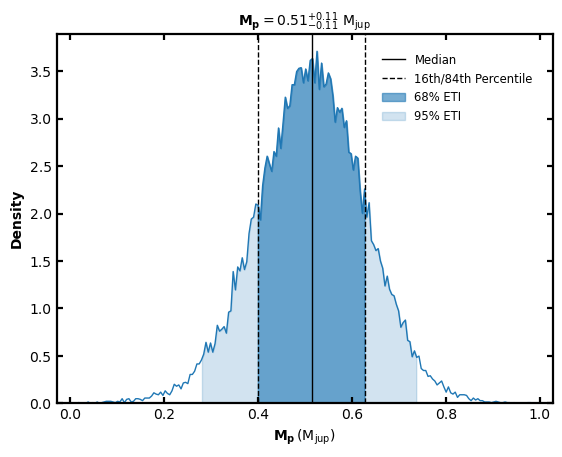

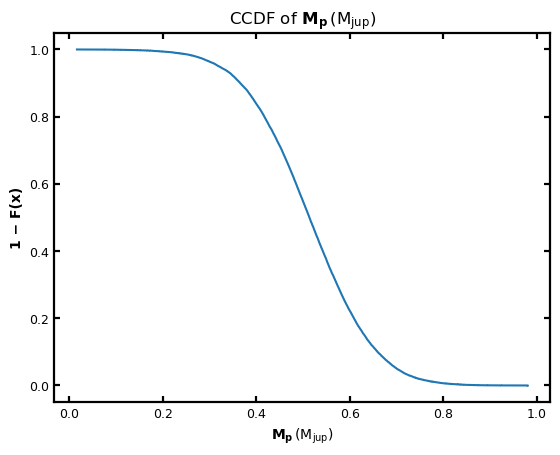

In [4]:
import sys
sys.path.append("../src")

from augment import Sampler
from augment.format import format_summary
from augment.plot import plot_posterior, plot_ecdf

import numpy as np
from astropy import units as u
from astropy.constants import G
from scipy.optimize import root_scalar

sampler2 = Sampler(n_samples=30000, seed=42)

sampler2.add("P", 10.0 * u.day, upper_error=1.1 * u.day, lower_error=1.3 * u.day, dist="normal")
sampler2.add("K", 50.0 * (u.m / u.s), upper_error=5.4 * (u.m / u.s), lower_error=2.2 * (u.m / u.s), dist="normal")
sampler2.add("e", 0.20 * u.dimensionless_unscaled, upper_error=0.06 * u.dimensionless_unscaled, lower_error=0.08 * u.dimensionless_unscaled, dist="normal", lower=0.0 * u.dimensionless_unscaled, upper=1.0 * u.dimensionless_unscaled)
sampler2.add("inc", 87.0 * u.deg, upper_error=1.5 * u.deg, lower_error=4.3 * u.deg, dist="normal", lower=1.6 * u.deg, upper=89.9 * u.deg)
sampler2.add("Mstar", 1.0 * u.Msun, upper_error=0.4 * u.Msun, lower_error=0.2 * u.Msun, dist="normal")

def M_p(P, K, e, inc, Mstar):
    P_sec = P.to_value(u.s)
    K_ms = K.to_value(u.m / u.s)
    e_val = e.to_value(u.dimensionless_unscaled)
    inc_rad = inc.to_value(u.rad)
    Mstar_kg = Mstar.to_value(u.kg)

    out = np.full(P_sec.shape, np.nan, dtype=float)
    G_si = G.to_value(u.m**3 / (u.kg * u.s**2))

    for i in range(P_sec.size):
        P_i = P_sec[i]
        K_i = K_ms[i]
        e_i = e_val[i]
        inc_i = inc_rad[i]
        Mstar_i = Mstar_kg[i]

        if not np.all(np.isfinite([P_i, K_i, e_i, inc_i, Mstar_i])):
            continue
        if (P_i <= 0) or (K_i <= 0) or (e_i < 0) or (e_i >= 1) or (Mstar_i <= 0):
            continue
        sin_i = np.sin(inc_i)
        if sin_i <= 0:
            continue

        pref = (2.0 * np.pi * G_si / P_i) ** (1.0 / 3.0)
        ecc = 1.0 / np.sqrt(1.0 - e_i**2)

        def f(Mp):
            return pref * (Mp * sin_i) / (Mstar_i + Mp) ** (2.0 / 3.0) * ecc - K_i

        # Small-mass approximation for initial scale
        Mp0 = (K_i * (Mstar_i ** (2.0 / 3.0)) * (P_i / (2.0 * np.pi * G_si)) ** (1.0 / 3.0) * np.sqrt(1.0 - e_i**2) / sin_i)
        if not np.isfinite(Mp0) or Mp0 <= 0:
            continue
        lo = Mp0 * 1e-3
        hi = Mp0 * 1e3
        try:
            # Ensure a sign change; widen if necessary
            if f(lo) * f(hi) > 0:
                lo = Mp0 * 1e-6
                hi = Mp0 * 1e6
            if f(lo) * f(hi) > 0:
                continue
            sol = root_scalar(f, bracket=(lo, hi), method="brentq")
            if sol.converged:
                out[i] = sol.root
        except Exception:
            continue

    return {"M_p": (out * u.kg).to(u.M_jup)}

out2 = sampler2.run(M_p, return_samples=True)
fmt_Mjup = format_summary(out2["summary"]["M_p"], samples=out2["samples"]["M_p"], target_unit=u.M_jup, sigfigs=2)
fmt_Mearth = format_summary(out2["summary"]["M_p"], samples=out2["samples"]["M_p"], target_unit=u.M_earth, sigfigs=2)
print(f"Mass of the Planet: {fmt_Mjup} | {fmt_Mearth}")

pstr = plot_posterior(out2, key="M_p", log10=False, kde=True, pretty_label=r"M_p", unit_label_overrides={"M_p": "M_{jup}"})

ecdf = plot_ecdf(out2, key="M_p", log10=False, pretty_label=r"M_p", unit_label_overrides={"M_p": "M_{jup}"}, ccdf=True)

# 3) Free-Fall Collapse and Virial Parameter Estimation

This example estimates whether a dense core is likely to be gravitationally bound by propagating uncertainties in its measured mass, radius, and linewidth.

The model uses three uncertain inputs:

- Core mass, $M$
- Core radius, $R$
- Observed line FWHM, $\Delta v$

From these, we calculate the mean density, free-fall time, virial mass, and virial parameter. This is a compact example because the derived quantities are directly connected to the question of whether a core may collapse under its own gravity.

The mean mass density is

$$
\rho = \frac{M}{V}
$$

where the spherical volume is

$$
V = \frac{4}{3}\pi R^3.
$$

The free-fall time is

$$
t_{\rm ff} =
\sqrt{
\frac{3\pi}{32G\rho}
}.
$$

The observed FWHM linewidth is converted to a one-dimensional velocity dispersion using

$$
\sigma_v =
\frac{\Delta v}{\sqrt{8\ln 2}}.
$$

For a uniform-density spherical core, the virial mass is

$$
M_{\rm vir} =
\frac{5R\sigma_v^2}{G}.
$$

The virial parameter is then

$$
\alpha_{\rm vir} =
\frac{M_{\rm vir}}{M}.
$$

A value of $\alpha_{\rm vir} \lesssim 1$ suggests that gravity is dynamically important and the core may be gravitationally bound. Larger values indicate that internal motions may provide enough support to resist collapse.

In [ ]:
import sys
sys.path.append("../src")

from augment import Sampler
from augment.format import format_summary
from augment.plot import plot_corner, plot_posterior

import numpy as np
from astropy import units as u
from astropy.constants import G

import numpy as np
from astropy import units as u
from astropy.constants import G

def freefall_collapse_model(M, R, dv):
    R_cgs = R.to(u.cm)
    M_cgs = M.to(u.g)
    dv_cgs = dv.to(u.cm / u.s)
    G_cgs = G.cgs

    V = (4 / 3) * np.pi * R_cgs**3

    rho = (M_cgs / V).to(u.g / u.cm**3)

    t_ff = np.sqrt(3 * np.pi / (32 * G_cgs * rho)).to(u.Myr)

    sigma_v = (dv_cgs / np.sqrt(8 * np.log(2))).to(u.cm / u.s)

    M_vir = (5 * R_cgs * sigma_v**2 / G_cgs).to(u.Msun)

    alpha_vir = (M_vir / M).decompose()

    return {
        "rho": rho,
        "t_ff": t_ff,
        "sigma_v": sigma_v,
        "M_vir": M_vir,
        "alpha_vir": alpha_vir,
    }

sampler = Sampler(n_samples=100_000, seed=42)

sampler.add(
    "M",
    50 * u.Msun,
    upper_error=15 * u.Msun,
    lower_error=10 * u.Msun,
    lower=0 * u.Msun,
)

sampler.add(
    "R",
    0.12 * u.pc,
    upper_error=0.03 * u.pc,
    lower_error=0.02 * u.pc,
    lower=0 * u.pc,
)

sampler.add(
    "dv",
    0.9 * u.km / u.s,
    upper_error=0.2 * u.km / u.s,
    lower_error=0.15 * u.km / u.s,
    lower=0 * u.km / u.s,
)

out = sampler.run(
    freefall_collapse_model,
    return_samples=True,
    error_budget_against="alpha_vir",
)

label_map = {
    "rho": r"\rho",
    "t_ff": r"t_{ff}",
    "M_vir": r"M_{vir}",
    "alpha_vir": r"\alpha_{vir}",
}

fig = plot_corner(
    out,
    keys=("rho", "t_ff", "M_vir", "alpha_vir"),
    log_keys=("rho", "t_ff", "M_vir", "alpha_vir"),
    label_map=label_map,
)

fig = plot_corner(
    out,
    keys=("rho", "t_ff", "M_vir", "alpha_vir"),
    label_map=label_map,
    title_fmt=".2e",
    # range_quantiles=(0.01, 0.99),
    plot_range=[
        (0.2e-19, 20e-19),   # rho
        (0.025, 0.25),     # t_ff
        (5, 50),          # M_vir
        (0.02, 2.0),       # alpha_vir
    ],
)

In [ ]:
from augment import format_summary_table


print(format_summary_table(
    out,
    keys=("rho", "t_ff", "M_vir", "alpha_vir"),
    # log_keys=("rho", "t_ff", "M_vir", "alpha_vir"),
    # target_units={
    #     "rho": u.Msun / u.pc**3,
    #     "t_ff": u.Myr,
    #     "M_vir": u.Msun,
    # },
    tablefmt="plain",
))

In [ ]:
from IPython.display import Markdown, display

display(Markdown(format_summary_table(
    out,
    keys=("rho", "t_ff", "M_vir", "alpha_vir"),
    log_keys=("rho", "t_ff", "M_vir", "alpha_vir"),
    include_fraction=True,
)))